<img src="recursos/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 6

Docentes: *LLAMEDO SORIA, Mariano* y *MOHAROS, David*

Autor: *MARCHESI, Matías Sebastián*


## Introducción

En esta tarea semanal se analiza una topología general de procesamiento digital de señales, compuesta por un filtro comb seguido de una red recursiva de segundo orden (biquad). 
<div style="text-align: center;">
  <img src="recursos/circuito.png" width="500">
</div>

El desarrollo se basa principalmente en el **Capítulo 26, “The Swiss Army Knife of Digital Networks”**, del libro **Streamlining Digital Signal Processing de Richard G. Lyons**, donde se analizarán diferentes configuraciones cambiándole los coeficientes a la transferencia. 

En cada configuración se verificarán su comportamiento mediante scripts de Python.

## Transferencia

A partir del diagrama de bloques de la siguiente figura se obtiene la transferencia
del sistema mediante el análisis de cada una de las etapas que lo componen.

<div style="text-align: center;">
  <img src="recursos/circuito.png" width="500">
</div>

Se considera inicialmente la etapa correspondiente al *Comb*.
Si $x(n)$ es la entrada del sistema, la salida de esta etapa resulta

$$
v(n)=x(n)-c_1x(n-N)
$$

y, aplicando transformada Z,

$$
V(z)=X(z)\left(1-c_1z^{-N}\right).
$$

Por lo tanto, la transferencia de esta primera etapa es

$$
H_{Comb}(z)=\frac{V(z)}{X(z)}
=(1-c_1z^{-N})
$$

Para la red de segundo orden, se considera $d(n)$ como la señal a la entrada del multiplicador $a_0$, que coincide con la salida del sumador ubicado al comienzo de la red recursiva.

Por lo que, analizando la red con detenimiento se puede determinar el valor de $D(z)$ recorriendo el diagrama en bloques.
$$D(z) = \frac{X(z)\cdot (1-c_1 z^{-N})}{1-z^{-1}a_0a_1-z^{-2}a_0a_2}$$

Y a su vez, se puede determinar el valor de la señal de salida utilizando esta señal $d(n)$:

$$Y(z) = D(z)\left(a_0b_0+a_0b_1z^{-1}+a_0b_2z^{-2}\right)$$

Reemplazando $d(n)$ por lo obtenido previamente:

$$Y(z) = \frac{X(z)\cdot (1-c_1z^{-N})}{1-z^{-1}a0\cdot a1 - z^{-2} a0\cdot a2} \cdot (a0\cdot b0 + a0\cdot b1 \cdot z^{-1} + a0\cdot b2 \cdot z^{-2})$$

Dividiendo todo por $a0$ y despejando se llega a $H(z)$:



<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$ \large H(z) = \frac{Y(z)}{X(z)} =
            \frac{(1-c_1z^{-N})(b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2})}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}}
$$
    </div>
</div>

## Filtro de media móvil

$$
a_0 = 1,\qquad a_1 = 1,\qquad a_2 = 0
$$

$$
b_0 = \frac{1}{N},\qquad b_1 = 0,\qquad b_2 = 0,\qquad c_1 = 1
$$

Partiendo de la transferencia general obtenida previamente y reemplazando
estos coeficientes, se obtiene

$$
H_{MA}(z) =
\frac{1}{N}
\frac{1-z^{-N}}{1-z^{-1}}
$$

Para simplificar esta expresión se utiliza la identidad de la suma
geométrica

$$
1-r^N=(1-r)(1+r+r^2+\dots+r^{N-1})
$$

Tomando $r=z^{-1}$, resulta

$$
1-z^{-N}
= (1-z^{-1})
\left(1+z^{-1}+z^{-2}+\dots+z^{-(N-1)}\right)
$$

Por lo tanto, se cancela el término $(1-z^{-1})$ y la transferencia queda


<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
H_{MA}(z)
= \frac{1}{N}
\left(
1+z^{-1}+z^{-2}+\dots+z^{-(N-1)}
\right)
$$
    </div>
</div>
Como tengo tres valores de N llegaré a tres transferencias:

Para $N=3$:

$$
H_{3_{\mathrm{MA}}}(z)=
\frac{1}{3}
\left(
1+z^{-1}+z^{-2}
\right)
$$

Para $N=4$:

$$
H_{4_{\mathrm{MA}}}(z)=
\frac{1}{4}
\left(
1+z^{-1}+z^{-2}+z^{-3}
\right)
$$

Para $N=5$:

$$
H_{5_{\mathrm{MA}}}(z)=
\frac{1}{5}
\left(
1+z^{-1}+z^{-2}+z^{-3}+z^{-4}
\right).
$$

#### Gráficos
A continuación se muestra en dos gráficos sus módulos y fases para poder compararlas.

##### Polos y Ceros

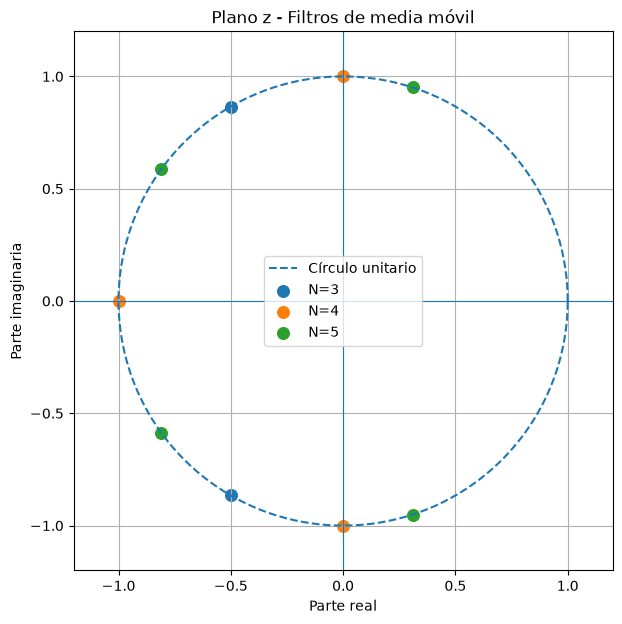

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Ns = [3, 4, 5]

theta = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(7, 7))

# Círculo unitario
plt.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    label='Círculo unitario'
)

for N in Ns:

    # Ceros del filtro de media móvil
    k = np.arange(1, N)
    zeros = np.exp(1j * 2 * np.pi * k / N)

    plt.scatter(
        np.real(zeros),
        np.imag(zeros),
        s=70,
        label=f'N={N}'
    )

# Ejes
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r'Parte real')
plt.ylabel(r'Parte imaginaria')

plt.title('Plano z - Filtros de media móvil')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

plt.gca().set_aspect('equal', adjustable='box')

plt.grid()
plt.legend()

plt.show()

##### Módulo

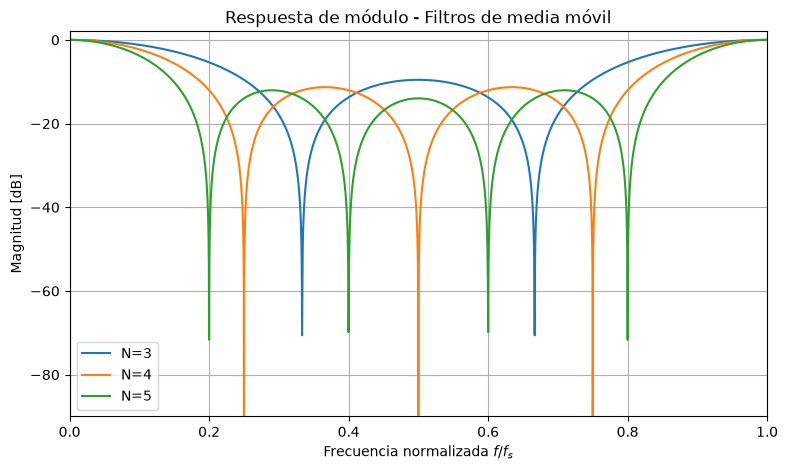

In [95]:
plt.figure(figsize=(9, 5))

for N in Ns:

    b = np.ones(N) / N
    a = [1]

    w, H = signal.freqz(
        b,
        a,
        worN=4096,
        whole=True
    )

    f = w / (2 * np.pi)

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(H), 1e-6)
    )

    plt.plot(
        f,
        magnitude_db,
        label=f'N={N}'
    )

plt.xlabel(r'Frecuencia normalizada $f/f_s$')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta de módulo - Filtros de media móvil')

plt.xlim(0, 1)
plt.ylim(-90, 2)

plt.grid()
plt.legend()
plt.show()

##### Fase

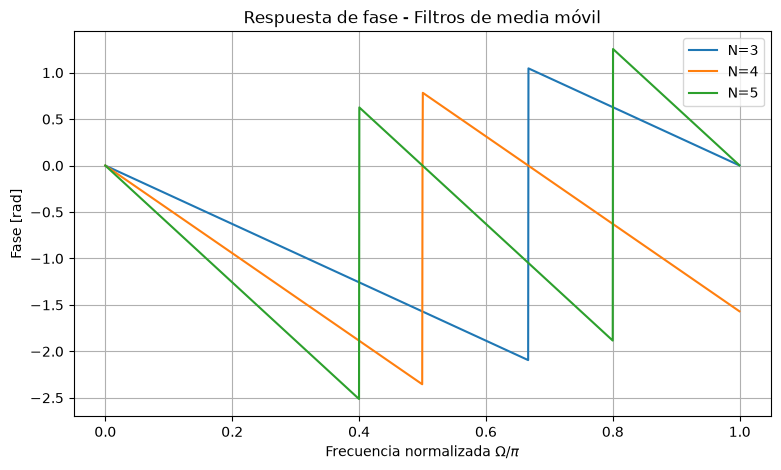

In [96]:
plt.figure(figsize=(9, 5))

for N in Ns:

    b = np.ones(N) / N
    a = [1]

    w, H = signal.freqz(b, a, worN=2048)

    plt.plot(
        w / np.pi,
        np.unwrap(np.angle(H)),
        label=f'N={N}'
    )

plt.xlabel(r'Frecuencia normalizada $\Omega/\pi$')
plt.ylabel('Fase [rad]')
plt.title('Respuesta de fase - Filtros de media móvil')
plt.grid()
plt.legend()
plt.show()

#### Diagrama en bloques

En base a la ecuación del filtro se hace el diagrama en bloques.
<div style="text-align: center;">
  <img src="recursos/moving_average_blocks.png" width="800">
</div>

### Característica FIR

Según Lyons, esta estructura es equivalente a un filtro FIR de convolución
directa de $N$ *taps*, con todos sus coeficientes iguales a $1/N$.
Por lo tanto, el filtro de media móvil implementado puede considerarse un
filtro de respuesta impulsional finita (FIR) con N impulsos.

Esto también puede observarse directamente a partir de la transferencia
obtenida, ya que el denominador desaparece luego de aplicar la identidad
geométrica, quedando únicamente una cantidad finita de términos retardados.

### Respuesta al impulso

Para este inciso, la consigna propone la siguiente respuesta al impulso:

$$
h(k)=(1,1,1,1,1,1,1).
$$

La estructura de media móvil obtenida anteriormente, para $N=7$, produce
una respuesta al impulso dada por

$$
h_{\mathrm{MA}}(k)=
\frac{1}{7}
(1,1,1,1,1,1,1).
$$

Por lo tanto, la topología utilizada implementa un promediador y no
directamente la respuesta al impulso propuesta.

Sin embargo, la misma estructura puede utilizarse para implementar la
respuesta solicitada modificando la ganancia del bloque de salida,
eliminando el factor $1/7$ en el coeficiente $b_0$. De esta manera, la estructura pasa de realizar
un promedio de las últimas siete muestras a realizar su suma.

Por lo tanto, **sí es posible implementar la respuesta al impulso dada
utilizando la misma topología, modificando únicamente su ganancia**.

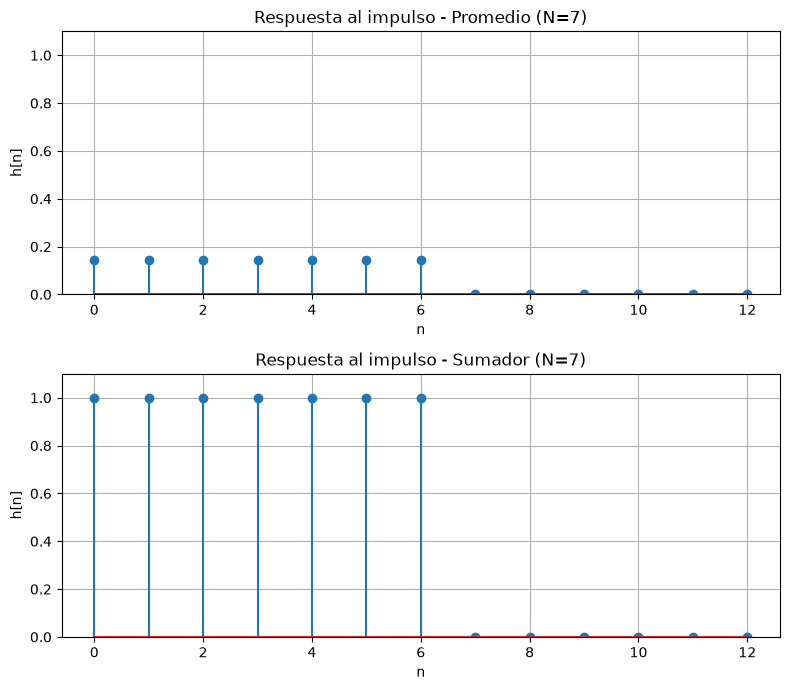

In [97]:
import numpy as np
import matplotlib.pyplot as plt

N = 7

n = np.arange(0, 13)

# Respuesta al impulso del promediador
h_promedio = np.zeros(len(n))
h_promedio[:N] = 1 / N

# Respuesta al impulso del sumador
h_sumador = np.zeros(len(n))
h_sumador[:N] = 1

plt.figure(figsize=(8, 7))

# Filtro de media móvil

plt.subplot(2, 1, 1)

plt.stem(n, h_promedio)

plt.xlabel("n")
plt.ylabel("h[n]")
plt.title("Respuesta al impulso - Promedio (N=7)")

plt.ylim(0, 1.1)
plt.grid(True)

# Filtro como sumador

plt.subplot(2, 1, 2)

plt.stem(n, h_sumador)

plt.xlabel("n")
plt.ylabel("h[n]")
plt.title("Respuesta al impulso - Sumador (N=7)")

plt.ylim(0, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

## Filtro Diferenciador

Para el desarrollo de este apartado se tomó como referencia el **Capítulo 19: "A Differentiator with a Difference"** del libro *Streamlining Digital Signal Processing* de Richard Lyons.

En particular, se utiliza el concepto de diferenciador por diferencia central desarrollado en la sección 19.1. Allí se presenta la aproximación de la derivada de una señal discreta mediante:

$$
y_{cd}(n)=\frac{x(n)-x(n-2)}{2}
$$

que corresponde a la ecuación (19-4) del libro.

### Obtención de los coeficientes

La transferencia correspondiente a la estructura propuesta es:

$$
H(z)=
(1-c_1z^{-N})
\frac{b_0+b_1z^{-1}+b_2z^{-2}}
{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}
$$

Para obtener el diferenciador por diferencia central se seleccionan:

$$
a_0=\frac{1}{2}, \qquad a_1=0, \qquad a_2=0
$$

$$
b_0=1, \qquad b_1=0, \qquad b_2=-1
$$

y

$$
c_1=0
$$

Reemplazando estos valores:

$$
H(z)=
\frac{1-z^{-2}}{2}
$$

Por lo tanto:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
H(z)=\frac{1}{2}(1-z^{-2})
$$
    </div>
</div>

y su correspondiente ecuación en diferencias es:

$$
y[n]=\frac{x[n]-x[n-2]}{2}
$$

Esta expresión coincide con el diferenciador por diferencia central presentado por Lyons.

### Polos y Ceros

La transferencia obtenida puede expresarse como:

$$
H(z)=\frac{1}{2}(1-z^{-2})
=\frac{z^2-1}{2z^2}
$$

Por lo tanto, presenta dos ceros:

$$
z_1=1,\qquad z_2=-1
$$

y dos polos coincidentes en el origen:

$$
p_1=p_2=0
$$

El diagrama de polos y ceros obtenido mediante Python permite visualizar estas singularidades.

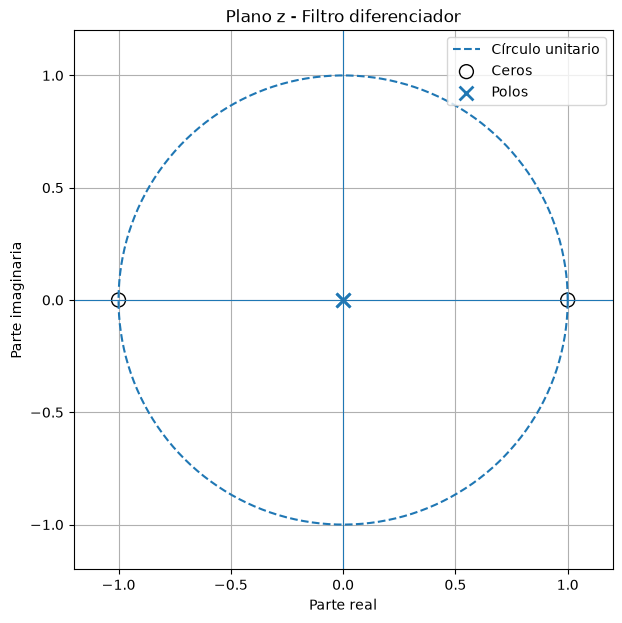

In [98]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 500)

# Ceros y polos
zeros = np.array([1, -1])
poles = np.array([0, 0])

plt.figure(figsize=(7, 7))

# Círculo unitario
plt.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    label='Círculo unitario'
)

# Ceros
plt.scatter(
    np.real(zeros),
    np.imag(zeros),
    s=100,
    marker='o',
    facecolors='none',
    edgecolors='black',
    label='Ceros'
)

# Polos
plt.scatter(
    np.real(poles),
    np.imag(poles),
    s=100,
    marker='x',
    linewidths=2,
    label='Polos'
)

# Ejes
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')

plt.title('Plano z - Filtro diferenciador')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

plt.gca().set_aspect('equal', adjustable='box')

plt.grid()
plt.legend()

plt.show()

### Respuesta en frecuencia

A partir de la transferencia obtenida:

$$
H(z)=\frac{1}{2}(1-z^{-2})
$$

se puede analizar su comportamiento en frecuencia evaluando la respuesta sobre la circunferencia unidad.

El módulo de la respuesta resulta:

$$
|H(e^{j\Omega})|=|\sin(\Omega)|
$$

Por otro lado, el diferenciador ideal presenta una respuesta de módulo proporcional a la frecuencia:

$$
|H_{\mathrm{ideal}}(e^{j\Omega})|=\Omega
$$

Para frecuencias bajas se cumple aproximadamente:

$$
\sin(\Omega)\approx\Omega
$$

por lo que el diferenciador por diferencia central presenta un comportamiento similar al diferenciador ideal en este rango.

Este comportamiento coincide con lo presentado por Lyons en el Capítulo 19, donde se muestra que la diferencia central permite aproximar la derivada para bajas frecuencias, mientras que la aproximación empeora al aumentar la frecuencia.

#### Módulo

Se obtiene el módulo de la señal:

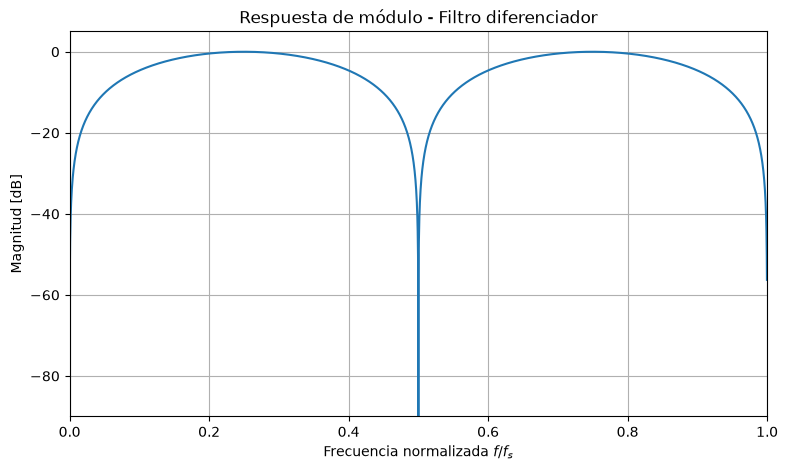

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes de H(z)
b = [0.5, 0, -0.5]
a = [1]

w, H = signal.freqz(
    b,
    a,
    worN=4096,
    whole=True
)

f = w / (2 * np.pi)

magnitude_db = 20 * np.log10(
    np.maximum(np.abs(H), 1e-6)
)

plt.figure(figsize=(9, 5))

plt.plot(
    f,
    magnitude_db
)

plt.xlabel(r'Frecuencia normalizada $f/f_s$')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta de módulo - Filtro diferenciador')

plt.xlim(0, 1)
plt.ylim(-90, 5)

plt.grid()
plt.show()

#### Fase

Se obtiene la representación de la fase.

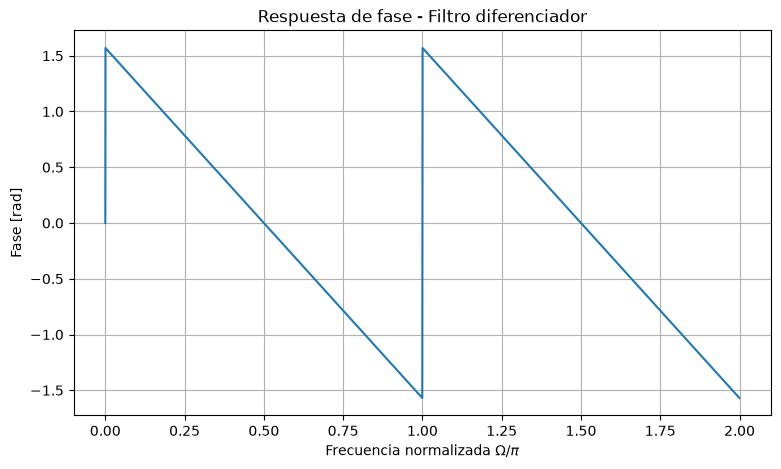

In [100]:
plt.figure(figsize=(9, 5))

plt.plot(
    w / np.pi,
    np.unwrap(np.angle(H))
)

plt.xlabel(r'Frecuencia normalizada $\Omega/\pi$')
plt.ylabel('Fase [rad]')
plt.title('Respuesta de fase - Filtro diferenciador')

plt.grid()
plt.show()

### Diagrama en bloques

En base a la ecuación del filtro se hace el diagrama en bloques.
<div style="text-align: center;">
  <img src="recursos/differentiator.png" width="600">
</div>

### Evaluación con una señal senoidal

Para verificar el comportamiento del filtro se utiliza una señal senoidal:

$$
x(t)=\sin(2\pi f_0t)
$$

cuya derivada es:

$$
\frac{dx(t)}{dt}=2\pi f_0\cos(2\pi f_0t)
$$

Se compara esta derivada ideal con la salida obtenida mediante el diferenciador discreto.

Para realizar la comparación en unidades de tiempo, se tiene en cuenta la frecuencia de muestreo:

$$
\frac{dx(t)}{dt}\approx
f_s\frac{x[n]-x[n-2]}{2}
$$

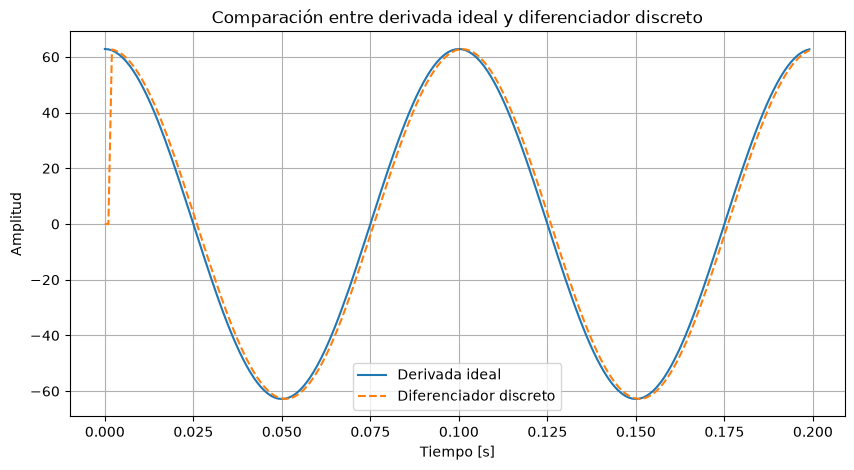

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs = 1000          # Frecuencia de muestreo [Hz]
f0 = 10            # Frecuencia de la señal [Hz]
N = 200            # Cantidad de muestras

n = np.arange(N)
t = n / fs

# Señal de entrada
x = np.sin(2 * np.pi * f0 * t)

# Filtro diferenciador por diferencia central
y = np.zeros(N)
y[2:] = (x[2:] - x[:-2]) / 2

# Derivada ideal
dy = 2 * np.pi * f0 * np.cos(2 * np.pi * f0 * t)

# Conversión a derivada respecto del tiempo
y_derivada = fs * y

# Representación
plt.figure(figsize=(10, 5))

plt.plot(t, dy, label="Derivada ideal")
plt.plot(t, y_derivada, "--", label="Diferenciador discreto")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación entre derivada ideal y diferenciador discreto")
plt.grid()
plt.legend()
plt.show()

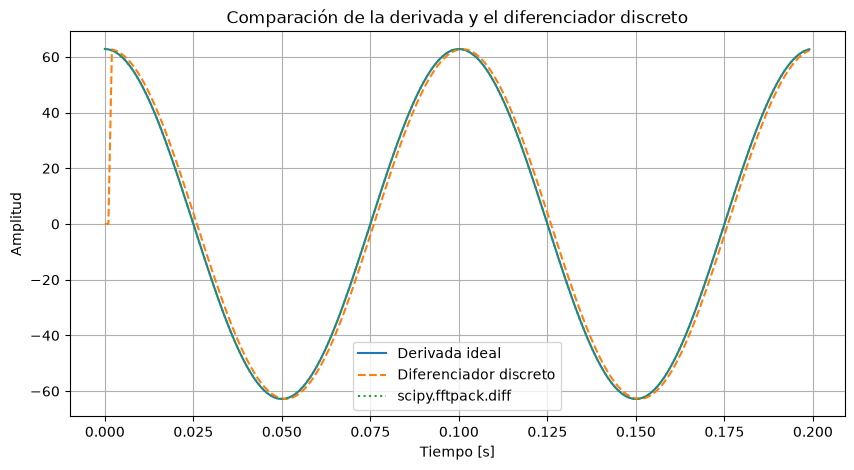

In [102]:
from scipy.fftpack import diff

# Derivada calculada mediante scipy.fftpack.diff
x_diff = diff(x, order=1, period=N/fs)

# Comparación
plt.figure(figsize=(10, 5))

plt.plot(t, dy, label="Derivada ideal")
plt.plot(t, y_derivada, "--", label="Diferenciador discreto")
plt.plot(t, x_diff, ":", label="scipy.fftpack.diff")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación de la derivada y el diferenciador discreto")
plt.grid()
plt.legend()
plt.show()

### Resultados

Para la señal utilizada, de frecuencia $f_0=10$ Hz y frecuencia de muestreo
$f_s=1000$ Hz, se obtiene:

$$
\Omega_0=2\pi\frac{f_0}{f_s}=0.02\pi
$$

Este valor corresponde a una frecuencia normalizada baja, por lo que la
aproximación del diferenciador por diferencia central resulta muy buena.

Como se observa en la figura, la salida del filtro presenta prácticamente la
misma forma que la derivada ideal. Esto concuerda con el comportamiento esperado
según el análisis presentado por Lyons para este tipo de diferenciador.

Como verificación adicional, se utilizó la función `diff` de
`scipy.fftpack` para calcular numéricamente la derivada de la señal mediante
su representación en series de Fourier. Para ello se indicó como período el
intervalo temporal correspondiente a las $N$ muestras analizadas.

La comparación muestra que la derivada obtenida mediante `scipy.fftpack.diff`
coincide con la derivada ideal, mientras que la salida del diferenciador
discreto presenta una aproximación muy cercana para esta frecuencia
normalizada baja.

## Filtro Elimina Continua

### Obtención de la transferencia

Partiendo de la transferencia general de la topología propuesta:

$$
H(z) =
(1-c_1z^{-N})
\frac{b_0+b_1z^{-1}+b_2z^{-2}}
{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}
$$

se consideran para este filtro los coeficientes:

$$
a_0=1,\qquad a_1=\beta,\qquad a_2=0
$$

$$
b_0=1,\qquad b_1=-1,\qquad b_2=0
$$

y se toma $c_1=0$, de manera que la etapa tipo comb no modifica la transferencia.

Reemplazando los coeficientes indicados en la expresión general se obtiene:

$$
H(z)=
\frac{1-z^{-1}}
{1-\beta z^{-1}}
$$

Para la primera parte del ejercicio se considera:

$$
\beta=0.9
$$

por lo que:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
H(z)=\frac{1-z^{-1}}{1-0.9z^{-1}}
$$
    </div>
</div>



Se observa que para $z=1$ el numerador se anula. Por lo tanto:

$$
H(1)=0
$$

lo que implica que la componente de continua es eliminada.

### Determinación del $\beta$

La segunda condición del ejercicio establece que la magnitud de la transferencia en

$$
\Omega_1=0.1\pi
$$

debe ser $3\,\mathrm{dB}$ menor que la magnitud en

$$
\Omega=\pi.
$$

Es decir:

$$
20\log_{10}
\left(
\frac{|H(e^{j0.1\pi})|}
{|H(e^{j\pi})|}
\right)
=-3\,\mathrm{dB}
$$

O lo que es lo mismo:

$$
\frac{|H(e^{j0.1\pi})|^2}
{|H(e^{j\pi})|^2}
=\frac{1}{2}
$$

Evaluando la transferencia sobre la circunferencia de radio unitaria:
$$
z=e^{j\Omega}
$$

por lo que:

$$
H(e^{j\Omega})=
\frac{1-e^{-j\Omega}}
{1-\beta e^{-j\Omega}}
$$

Para obtener su módulo al cuadrado utilizamos:

$$
|z|^2=z\,z^*
$$

En el numerador:

$$
|1-e^{-j\Omega}|^2=
(1-e^{-j\Omega})(1-e^{j\Omega})
$$

$$
=2-2\cos(\Omega)
$$

Mientras que para el denominador:

$$
|1-\beta e^{-j\Omega}|^2=
(1-\beta e^{-j\Omega})
(1-\beta e^{j\Omega})
$$

$$
=1+\beta^2-2\beta\cos(\Omega)
$$

Por lo tanto:




<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
|H(e^{j\Omega})|^2=
\frac{2-2\cos(\Omega)}
{1+\beta^2-2\beta\cos(\Omega)}
$$
    </div>
</div>

Para $\Omega=\pi$:

$$
\cos(\pi)=-1
$$

por lo que:

$$
|H(e^{j\pi})|^2=
\frac{2-2(-1)}
{1+\beta^2-2\beta(-1)}
$$

$$
|H(e^{j\pi})|^2=
\frac{4}{(1+\beta)^2}
$$

Para $\Omega_1=0.1\pi$:

$$
|H(e^{j0.1\pi})|^2=
\frac{2-2\cos(0.1\pi)}
{1+\beta^2-2\beta\cos(0.1\pi)}
$$

Imponiendo que esta magnitud sea $3\,\mathrm{dB}$ menor que la correspondiente a $\Omega=\pi$:

$$
\frac{|H(e^{j0.1\pi})|^2}
{|H(e^{j\pi})|^2}=
\frac{1}{2}
$$

se obtiene:

$$
\frac{
2-2\cos(0.1\pi)
}{
1+\beta^2-2\beta\cos(0.1\pi)
}
\frac{(1+\beta)^2}{4}=
\frac{1}{2}
$$

Resolviendo la ecuación antes presentada se obtiene una expresión cuadrática con $\beta$ como incógnita. Se obtienen dos soluciones

$$
\beta_1 \approx 0.7265425
$$

$$
\beta_2 \approx 1.3763819
$$

Para garantizar la estabilidad debo mantener mi polo dentro del circulo de radio unidad, por lo que:

$$
|\beta|<1
$$

Por lo tanto, se selecciona:

$$
\beta\approx0.7265
$$

Con este valor, la transferencia final queda:



<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
H(z)=
\frac{1-z^{-1}}
{1-0.7265z^{-1}}
$$
    </div>
</div>

### Gráficos

Se procede a realizar con scripts de Python gráficos comparativos.

#### Polos y Ceros

A partir de

$$
H(z)=\frac{1-z^{-1}}{1-\beta z^{-1}}
$$

multiplicando numerador y denominador por $z$:

$$
H(z)=\frac{z-1}{z-\beta}
$$

se observa que existe un cero en $z=1$ y un polo en $z=\beta$.

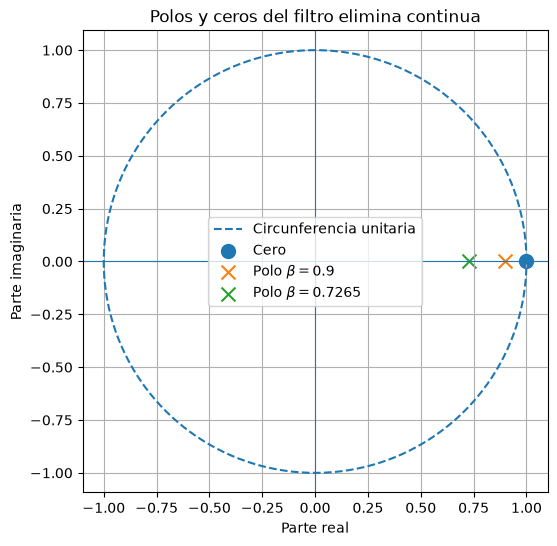

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

beta_1 = 0.9
beta_2 = 0.7265425

ceros = [1]

polos_1 = [beta_1]
polos_2 = [beta_2]

plt.figure(figsize=(6, 6))

# Circunferencia unitaria
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', label='Circunferencia unitaria')

# Cero
plt.scatter(np.real(ceros), np.imag(ceros),
            marker='o', s=100, label='Cero')

# Polos
plt.scatter(np.real(polos_1), np.imag(polos_1),
            marker='x', s=100, label=r'Polo $\beta=0.9$')

plt.scatter(np.real(polos_2), np.imag(polos_2),
            marker='x', s=100, label=r'Polo $\beta=0.7265$')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r'Parte real')
plt.ylabel(r'Parte imaginaria')
plt.title('Polos y ceros del filtro elimina continua')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

#### Modulo

Se muestra una gráfica comparativa del módulo para $\beta=0.9$ y para el calculado anteriormente
$
\beta=0.7265
$

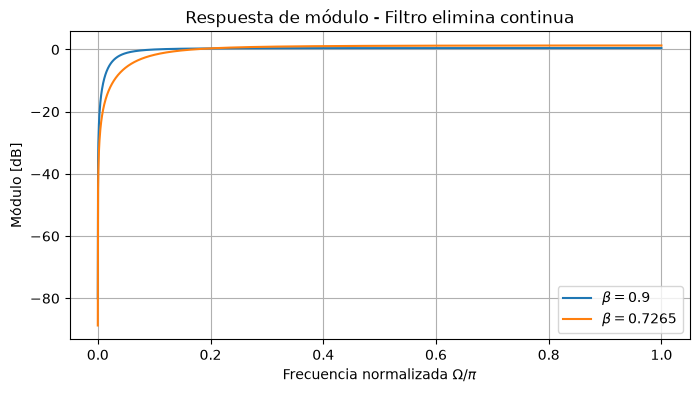

In [104]:
Omega = np.linspace(1e-5, np.pi, 2000)

def H_dc_blocker(Omega, beta):
    return (1 - np.exp(-1j * Omega)) / (1 - beta * np.exp(-1j * Omega))

H_09 = H_dc_blocker(Omega, beta_1)
H_opt = H_dc_blocker(Omega, beta_2)

mod_09 = 20 * np.log10(np.abs(H_09))
mod_opt = 20 * np.log10(np.abs(H_opt))

fase_09 = np.unwrap(np.angle(H_09)) * 180 / np.pi
fase_opt = np.unwrap(np.angle(H_opt)) * 180 / np.pi

plt.figure(figsize=(8, 4))

plt.plot(Omega / np.pi, mod_09, label=r'$\beta=0.9$')
plt.plot(Omega / np.pi, mod_opt, label=r'$\beta=0.7265$')

plt.xlabel(r'Frecuencia normalizada $\Omega/\pi$')
plt.ylabel('Módulo [dB]')
plt.title('Respuesta de módulo - Filtro elimina continua')
plt.grid()
plt.legend()
plt.show()

#### Fase

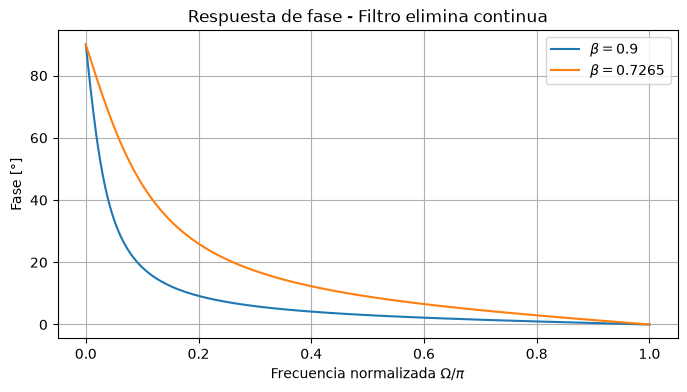

In [105]:
plt.figure(figsize=(8, 4))

plt.plot(Omega / np.pi, fase_09, label=r'$\beta=0.9$')
plt.plot(Omega / np.pi, fase_opt, label=r'$\beta=0.7265$')

plt.xlabel(r'Frecuencia normalizada $\Omega/\pi$')
plt.ylabel('Fase [°]')
plt.title('Respuesta de fase - Filtro elimina continua')
plt.grid()
plt.legend()
plt.show()

Analizando la respuesta en módulo se observa lo antes mencionado de que en continua ($0 Hz$) se elimina la continua, por lo que los gráficos condicen con lo obtenido analíticamente.

### Diagrama en bloques

En base a la ecuación del filtro se hace el diagrama en bloques.
<div style="text-align: center;">
  <img src="recursos/dc_blocker.png" width="700">
</div>

## Filtro Peine

En este inciso se analizará el filtro peine utilizando los parámetros $c_1 = -1$ y $N=8$.

### Obtención de la transferencia

Partiendo de la transferencia general:

$$ \large
H(z)=\left(1-c_1z^{-N}\right)
\frac{b_0+b_1z^{-1}+b_2z^{-2}}
{\frac{1}{a_0}-\frac{a_1}{a_0}z^{-1}-\frac{a_2}{a_0}z^{-2}}.
$$

Para este caso, la consigna indica $c_1=-1$ y $N=8$. Además, al no especificarse otros coeficientes, se toman

$$
a_0=1,\qquad a_1=a_2=0,
$$

$$
b_0=1,\qquad b_1=b_2=0.
$$

Se obtiene la transferencia del filtro peine:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
H(z)=1+z^{-8}
$$
    </div>
</div>




### Gráficos

Mediante scripts de python se obtendrán los polos y ceros, modulo y fase.

#### Polos y ceros

Partiendo de

$$
H(z)=1+z^{-8},
$$

multiplicando numerador y denominador por $z^8$ se obtiene

$$
H(z)=\frac{z^8+1}{z^8}.
$$

Los **ceros** se obtienen de

$$
z^8+1=0
$$

O sea, se tienen ocho ceros distribuidos uniformemente sobre la circunferencia unidad.

A su vez, se tienen 8 polos en el origen.

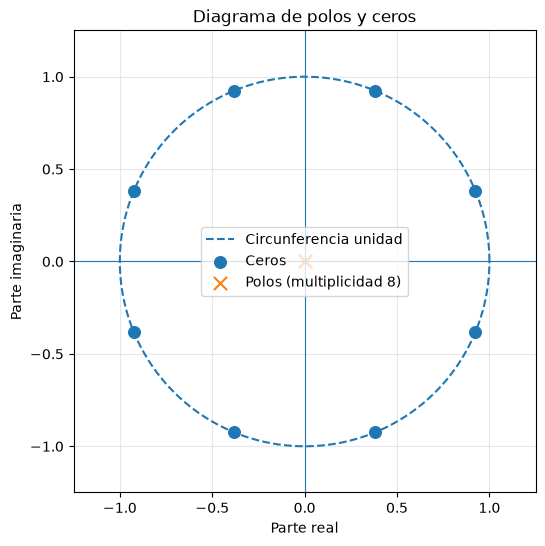

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del filtro
c1 = -1
N = 8

a0, a1, a2 = 1, 0, 0
b0, b1, b2 = 1, 0, 0

# Polos y ceros
k = np.arange(N)

zeros = np.exp(1j * (2*k + 1) * np.pi / N)
poles = np.zeros(N, dtype=complex)

# Circunferencia unidad
theta = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(6, 6))

plt.plot(
    np.cos(theta),
    np.sin(theta),
    linestyle="--",
    label="Circunferencia unidad"
)

# Ceros
plt.scatter(
    zeros.real,
    zeros.imag,
    marker="o",
    s=70,
    label="Ceros"
)

# Polos
plt.scatter(
    poles.real,
    poles.imag,
    marker="x",
    s=90,
    label="Polos (multiplicidad 8)"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True, alpha=0.3)

plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)

plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.title("Diagrama de polos y ceros")
plt.legend()

plt.show()

#### Módulo

Evaluando la transferencia con $
z=e^{j\Omega}
$ se obtiene:

$$
H(e^{j\Omega})=1+e^{-j8\Omega}.
$$

Para obtener el módulo, se utiliza

$$
|H(e^{j\Omega})|^2=
\left(1+e^{-j8\Omega}\right)
\left(1+e^{j8\Omega}\right).
$$

Desarrollando,

$$
|H(e^{j\Omega})|^2
=2+2\cos(8\Omega).
$$

Aplicando la identidad

$$
1+\cos(2\theta)=2\cos^2(\theta),
$$

resulta

$$
|H(e^{j\Omega})|^2=4\cos^2(4\Omega),
$$

y por lo tanto

$$
|H(e^{j\Omega})|=2|\cos(4\Omega)|
$$


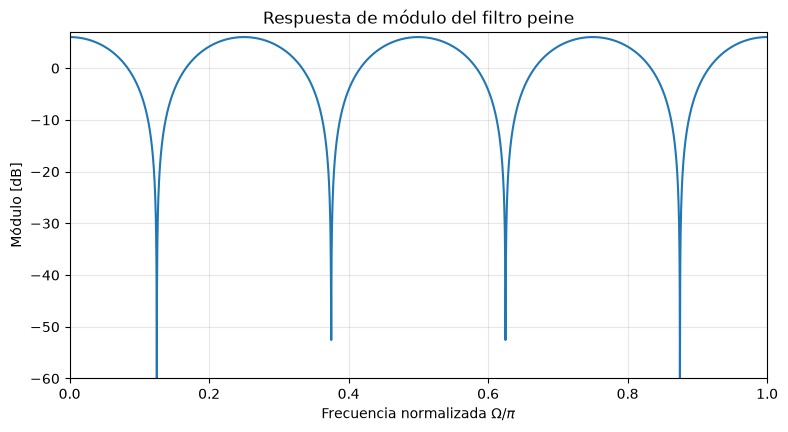

In [107]:
# Respuesta en frecuencia
Omega = np.linspace(0, np.pi, 4000)
H = 1 + np.exp(-1j * N * Omega)

modulo = np.abs(H)
modulo_db = 20 * np.log10(np.maximum(modulo, 1e-12))

plt.figure(figsize=(9, 4.5))
plt.plot(Omega / np.pi, modulo_db)

plt.xlabel(r"Frecuencia normalizada $\Omega/\pi$")
plt.ylabel("Módulo [dB]")
plt.title("Respuesta de módulo del filtro peine")
plt.grid(True, alpha=0.3)
plt.ylim(-60, 7)
plt.xlim(0, 1)
plt.show()

#### Fase

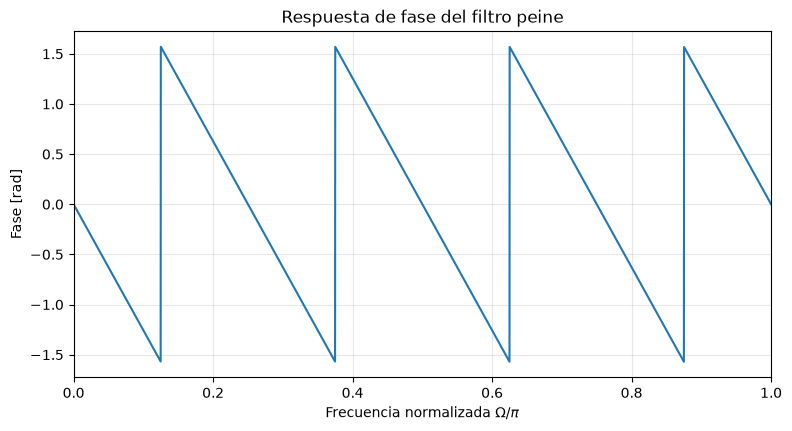

In [108]:
# Fase principal
fase = np.angle(H)

plt.figure(figsize=(9, 4.5))
plt.plot(Omega / np.pi, fase)

plt.xlabel(r"Frecuencia normalizada $\Omega/\pi$")
plt.ylabel("Fase [rad]")
plt.title("Respuesta de fase del filtro peine")
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

### Diagrama en bloques

En base a la ecuación del filtro se hace el diagrama en bloques.
<div style="text-align: center;">
  <img src="recursos/comb.png" width="600">
</div>

### Frecuencias de nulls y peaks

#### Nulls

Para obtener los nulls se debe evaluar cuando el módulo de la transferencia da 0.

$$
|H(e^{j\Omega})|=0.
$$

De la expresión obtenida,

$$
2|\cos(4\Omega)|=0,
$$

por lo que

$$
\cos(4\Omega)=0.
$$

Entonces,

$$
4\Omega=\frac{(2k+1)\pi}{2},
$$

y finalmente

$$
\Omega_{null}=\frac{(2k+1)\pi}{8}.
$$

Dentro del intervalo $0\leq\Omega\leq\pi$ se obtienen

$$
\Omega_{null}=
\left[
\frac{\pi}{8},
\frac{3\pi}{8},
\frac{5\pi}{8},
\frac{7\pi}{8}
\right].
$$

#### Peaks

Para obtener los peaks se debe evaluar el punto máximo del coseno. Esto ocurre en múltiplos de $\pi$. Por lo que:

$$
4\Omega=k\pi,
$$

por lo que

$$
\Omega_{peak}=\frac{k\pi}{4}
$$

En $0\leq\Omega\leq\pi$:

$$
\Omega_{peak}=
\left[
0,
\frac{\pi}{4},
\frac{\pi}{2},
\frac{3\pi}{4},
\pi
\right].
$$

En estos puntos el módulo alcanza

$$
|H(e^{j\Omega})|=2,
$$

equivalente a aproximadamente $6.02\,\text{dB}$.

### Frecuencia de Sampling

Se propone ahora una frecuencia de sampleo:

$$f_s = 1KHz$$

La relación entre frecuencia digital normalizada y frecuencia física es

$$
\Omega=2\pi\frac{f}{f_s}.
$$

Por lo tanto,

$$
f=\frac{\Omega}{2\pi}f_s
$$

Expresando los resultados antes obtenidos en frecuencia, teniendo en cuenta que se mostrarán resultados desde el 0 (Continua) hasta la mitad de la frecuencia de sampleo por Nyquist.

#### Nulls

A partir de

$$
\Omega_{null}=\frac{(2k+1)\pi}{8},
$$

se obtiene

$$
f_{null}
=\frac{2k+1}{16}f_s.
$$

Para $f_s=1000\,\text{Hz}$:

$$
f_{nulo}=
[62.5,\;187.5,\;312.5,\;437.5]\,Hz
$$

#### Peaks

A partir de

$$
\Omega_{peak}=\frac{k\pi}{4},
$$

se obtiene

$$
f_{peak}=\frac{k}{8}f_s.
$$

Por lo tanto,

$$
f_{peak}=
[0,\;125,\;250,\;375,\;500]\,\text{Hz}
$$

El último máximo coincide con la frecuencia de Nyquist, $f_s/2=500\,\text{Hz}$.

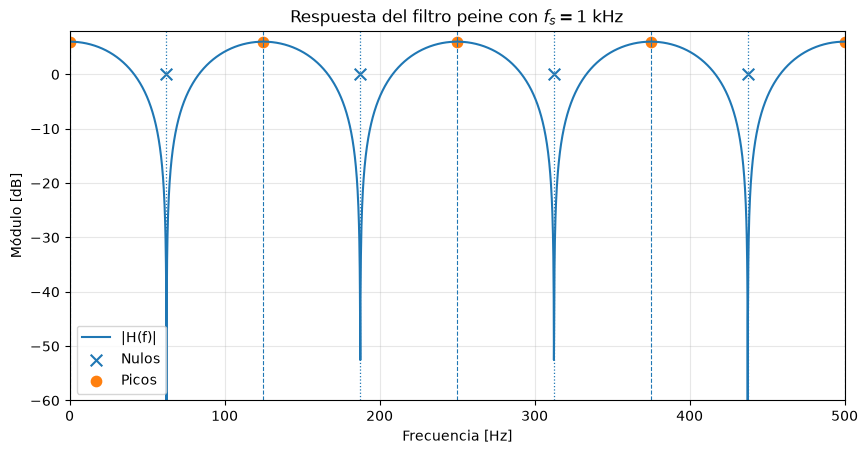

In [109]:
# Frecuencia de muestreo propuesta
fs = 1000  # Hz

# Frecuencias de nulos y picos
k_null = np.arange(4)
f_null = (2*k_null + 1) * fs / (2*N)

k_peak = np.arange(5)
f_peak = k_peak * fs / N

# Conversión de frecuencia normalizada a Hz
f = Omega / (2*np.pi) * fs

plt.figure(figsize=(10, 4.8))
plt.plot(f, modulo_db, label="|H(f)|")

plt.scatter(f_null, np.zeros_like(f_null), marker="x", s=70,
            label="Nulos")
plt.scatter(f_peak, np.full_like(f_peak, 6.02), marker="o", s=55,
            label="Picos")

for fn in f_null:
    plt.axvline(fn, linestyle=":", linewidth=0.9)

for fp in f_peak:
    plt.axvline(fp, linestyle="--", linewidth=0.8)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo [dB]")
plt.title("Respuesta del filtro peine con $f_s = 1$ kHz")
plt.grid(True, alpha=0.3)
plt.xlim(0, fs/2)
plt.ylim(-60, 8)
plt.legend()
plt.show()